In [2]:
import pandas as pd

df_24 = pd.read_excel(r"C:\Users\Hiba\Downloads\FY 24_25.xlsx")


In [3]:
df_25 = pd.read_excel(r"C:\Users\Hiba\Downloads\FY 25-26.xlsx")

In [4]:
df = pd.concat([df_24, df_25], ignore_index=True)

In [5]:
df.head()

,Branch Name,Branch Code,State,Date of Loan,Tenure of Loan,Tenure Days,Scheme Code,Scheme,Account Number,Net Weight,On Boarding Interest Rate,Disbursed Amount,Current Rate of Interest,Closure Amount
0,THENKURISSI,8,KERALA,2024-09-16,2025-09-16,365,430,INDEL STAR_DC,804300013156,19.7,17.0,96050.0,17.0,112378.50
1,THENKURISSI,8,KERALA,2024-04-12,2025-04-12,365,366,INDEL SPECIAL_DC,803660012772,29.0,11.5,132000.0,11.5,147180.00
2,THENKURISSI,8,KERALA,2024-06-24,2025-06-24,365,407,INDEL_POWER_DC,804070012951,11.3,18.0,44900.0,18.0,52982.00
3,NHANGATTIRI,10,KERALA,2024-11-28,2025-11-27,364,447,INDEL SECURE_IND,1004470011842,23.0,15.0,100100.0,15.0,115115.00
4,NHANGATTIRI,10,KERALA,2024-04-12,2025-04-12,365,370,INDEL STABLE_DC,1003700011227,8.1,16.0,35368.0,16.0,41026.88


In [6]:
df.shape

(1248065, 14)

In [7]:
df.columns

Index(['Branch Name', 'Branch Code', 'State', 'Date of Loan', 'Tenure of Loan',
       'Tenure Days', 'Scheme Code', 'Scheme', 'Account Number', 'Net Weight',
       'On Boarding Interest Rate', 'Disbursed Amount',
       'Current Rate of Interest', 'Closure Amount'],
      dtype='object')

In [8]:
df.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [9]:
df.isnull().sum()

Branch Name                  0
Branch Code                  0
State                        0
Date of Loan                 0
Tenure of Loan               0
Tenure Days                  0
Scheme Code                  0
Scheme                       0
Account Number               0
Net Weight                   0
On Boarding Interest Rate    0
Disbursed Amount             0
Current Rate of Interest     0
Closure Amount               0
dtype: int64

In [10]:
df = df.drop(columns=["Account Number","Closure Amount"])

In [11]:
df["Month"] = df["Date of Loan"].dt.month
df["Year"] = df["Date of Loan"].dt.year
df["Quarter"] = df["Date of Loan"].dt.quarter

In [12]:
df["Interest_jump"] = df["Current Rate of Interest"] - df["On Boarding Interest Rate"]

In [13]:
y = df["Disbursed Amount"]

In [14]:
X = df[[
"Net Weight",
"Tenure Days",
"On Boarding Interest Rate",
"Current Rate of Interest",
"Interest_jump",
"Month",
"Quarter"
]]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
X_train.shape

(998452, 7)

In [17]:
from sklearn.ensemble import RandomForestRegressor

In [18]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [19]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_pred = rf.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [22]:
mae = mean_absolute_error(y_test, y_pred)
mae

10148.890756890407

In [23]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(26212.239530116203)

In [24]:
r2 = r2_score(y_test, y_pred)
r2

0.9779217207732449

In [25]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False)

Net Weight                   0.938930
On Boarding Interest Rate    0.025339
Month                        0.021283
Quarter                      0.009592
Current Rate of Interest     0.002300
Tenure Days                  0.001847
Interest_jump                0.000707
dtype: float64

<Axes: >

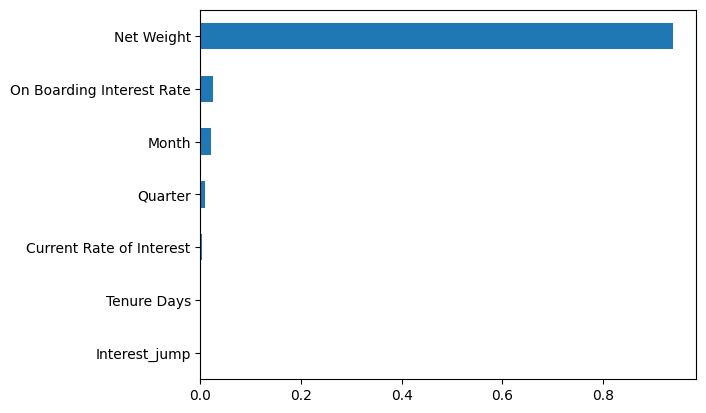

In [26]:
importance.sort_values().plot(kind="barh")

In [28]:
df = pd.get_dummies(df, columns=["Scheme","State"], drop_first=True)

In [29]:
y = df["Disbursed Amount"]

In [30]:
X = df.drop(columns=[
"Disbursed Amount",
"Branch Name",
"Branch Code",
"Date of Loan",
"Tenure of Loan"
])

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
n_estimators=100,
random_state=42,
n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
y_pred = rf.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 8974.102580975285
RMSE: 23151.970987485885
R2: 0.9827760441001069


In [35]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10)

Net Weight                   0.934289
Scheme Code                  0.030100
Month                        0.014256
Quarter                      0.007836
On Boarding Interest Rate    0.003244
Year                         0.003211
Current Rate of Interest     0.001297
State_KARNATAKA              0.000477
Scheme_INDEL_IND_NEW         0.000471
State_MAHARASHTRA            0.000459
dtype: float64

<Axes: >

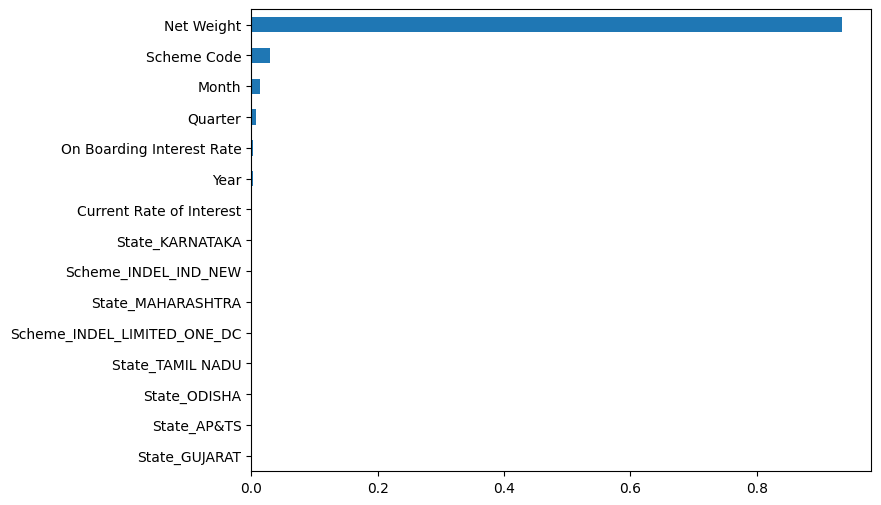

In [36]:
importance.sort_values().tail(15).plot(kind="barh", figsize=(8,6))

In [37]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 9.3 MB/s eta 0:00:11
   - -------------------------------------- 3.1/101.7 MB 8.4 MB/s eta 0:00:12
   - -------------------------------------- 4.5/101.7 MB 7.9 MB/s eta 0:00:13
   -- ------------------------------------- 6.3/101.7 MB 8.2 MB/s eta 0:00:12
   --- ------------------------------------ 8.4/101.7 MB 8.6 MB/s eta 0:00:11
   ---- ----------------------------------- 10.2/101.7 MB 8.7 MB/s eta 0:00:11
   ---- ----------------------------------- 12.1/101.7 MB 8.6 MB/s eta 0:00:11
   ----- ---------------------------------- 12.8/101.7 MB 8.6 MB/s eta 0:00:11
   ----- ---------------------------------- 13.1/101.7 MB 7.2 MB/s eta 0:00:13
   ----- ---------------------------------- 14.7/101.7 MB 7.9 MB/s eta 0:00:12
   ----- ---------------------------------- 14.7/101.7 MB 7.9 MB/s eta 0:00:12
   ----- ---------------------------------- 15.2/101.7 MB 6.2 MB/


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from xgboost import XGBRegressor

In [39]:
from xgboost import XGBRegressor

In [41]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [42]:
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:
y_pred_xgb = xgb.predict(X_test)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

MAE: 10457.314173639339
RMSE: 48259.87802109715
R2: 0.9251607536299119


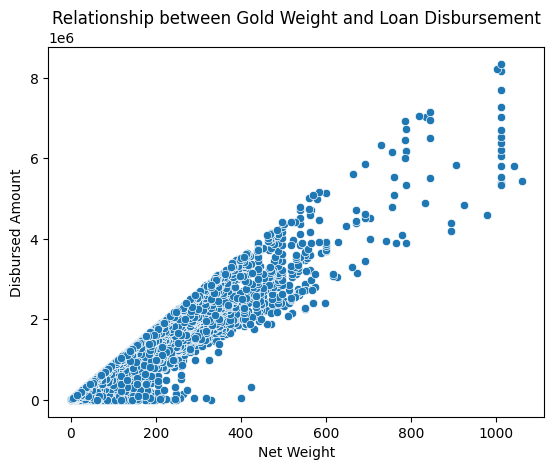

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="Net Weight", y="Disbursed Amount", data=df)

plt.title("Relationship between Gold Weight and Loan Disbursement")
plt.show()

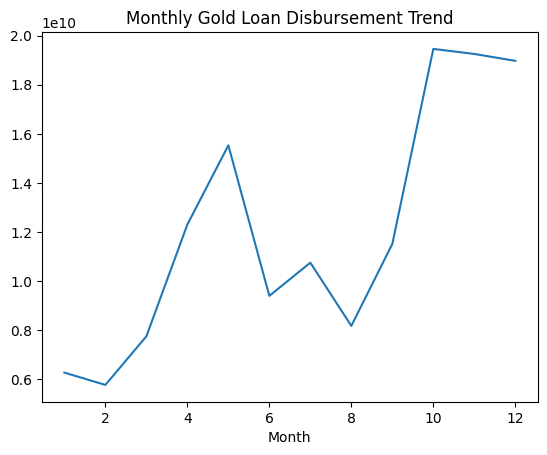

In [47]:
df.groupby("Month")["Disbursed Amount"].sum().plot(kind="line")

plt.title("Monthly Gold Loan Disbursement Trend")
plt.show()

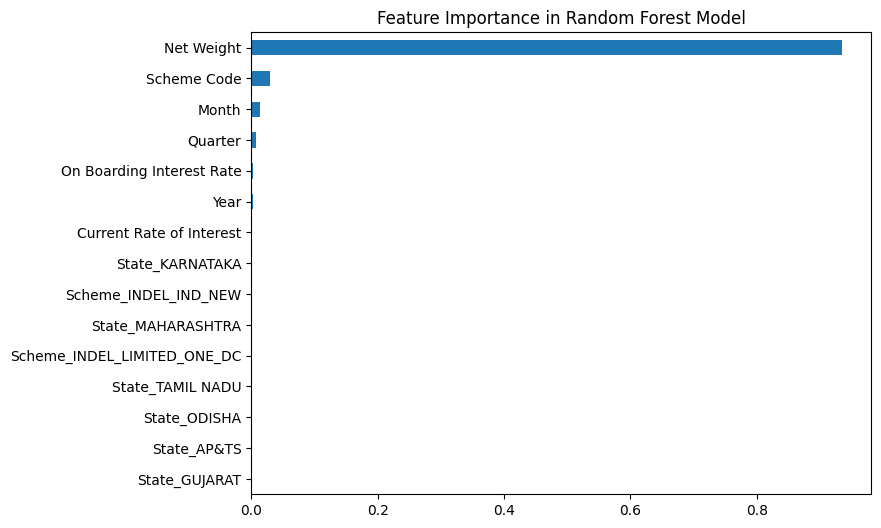

In [48]:
importance.sort_values().tail(15).plot(kind="barh", figsize=(8,6))

plt.title("Feature Importance in Random Forest Model")
plt.show()

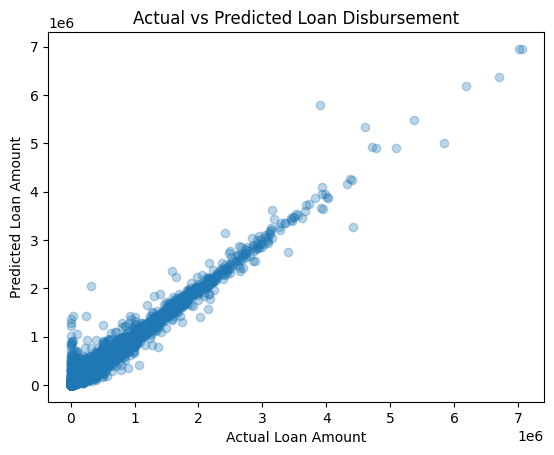

In [49]:
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted Loan Disbursement")
plt.show()

In [51]:
import pandas as pd

df_24 = pd.read_excel(r"C:\Users\Hiba\Downloads\FY 24_25.xlsx")
df_25 = pd.read_excel(r"C:\Users\Hiba\Downloads\FY 25-26.xlsx")

In [52]:
df_vis = pd.concat([df_24, df_25], ignore_index=True)

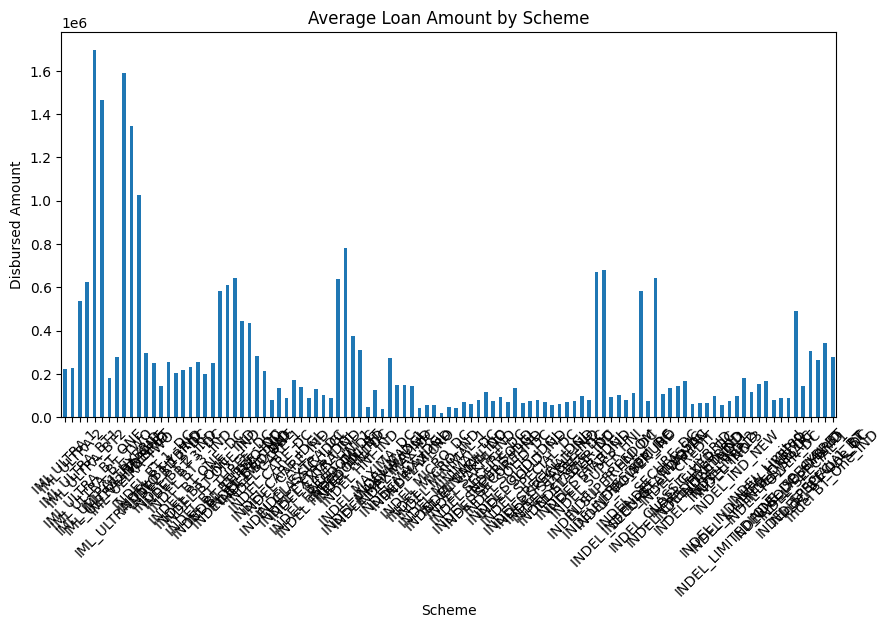

In [53]:
df_vis.groupby("Scheme")["Disbursed Amount"].mean().plot(kind="bar", figsize=(10,5))

plt.title("Average Loan Amount by Scheme")
plt.ylabel("Disbursed Amount")
plt.xticks(rotation=45)
plt.show()

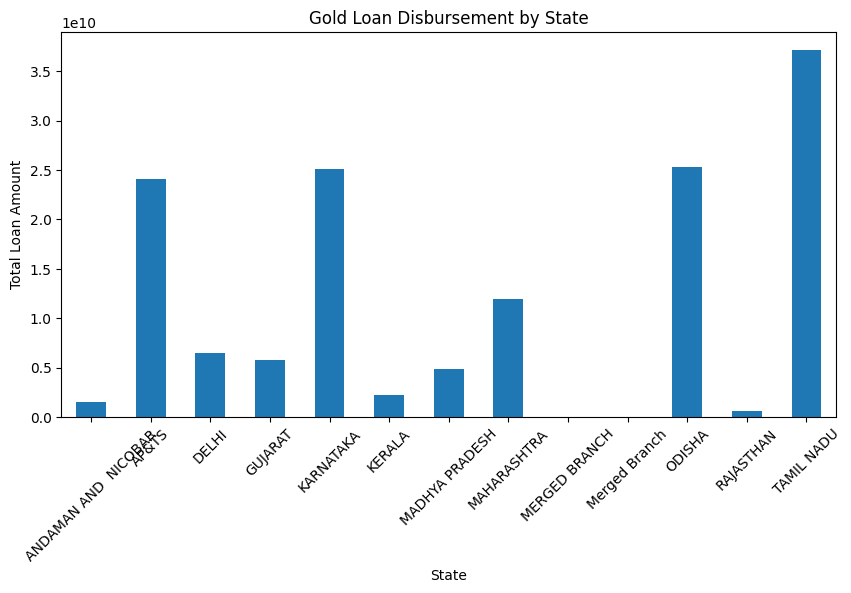

In [60]:
import matplotlib.pyplot as plt

df_vis.groupby("State")["Disbursed Amount"].sum().plot(kind="bar", figsize=(10,5))

plt.title("Gold Loan Disbursement by State")
plt.ylabel("Total Loan Amount")
plt.xticks(rotation=45)

plt.show()

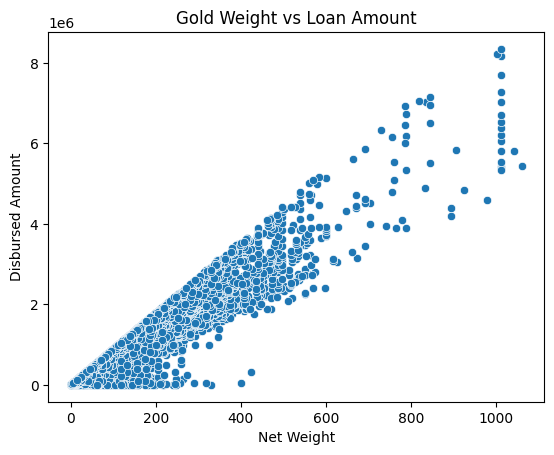

In [55]:
sns.scatterplot(x="Net Weight", y="Disbursed Amount", data=df)
plt.title("Gold Weight vs Loan Amount")
plt.show()

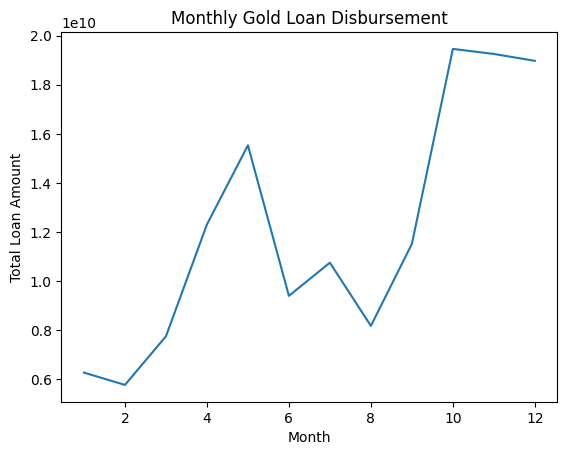

In [56]:
df.groupby("Month")["Disbursed Amount"].sum().plot(kind="line")

plt.title("Monthly Gold Loan Disbursement")
plt.ylabel("Total Loan Amount")
plt.show()

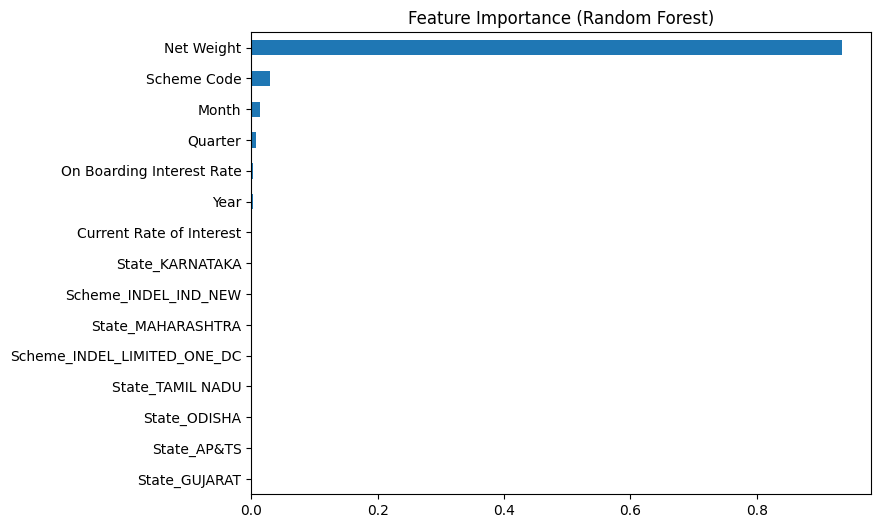

In [57]:
importance.sort_values().tail(15).plot(kind="barh", figsize=(8,6))

plt.title("Feature Importance (Random Forest)")
plt.show()

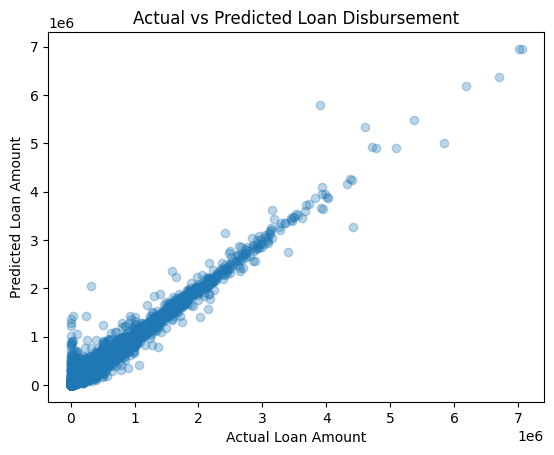

In [58]:
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted Loan Disbursement")

plt.show()

<Axes: xlabel='Net Weight', ylabel='Disbursed Amount'>

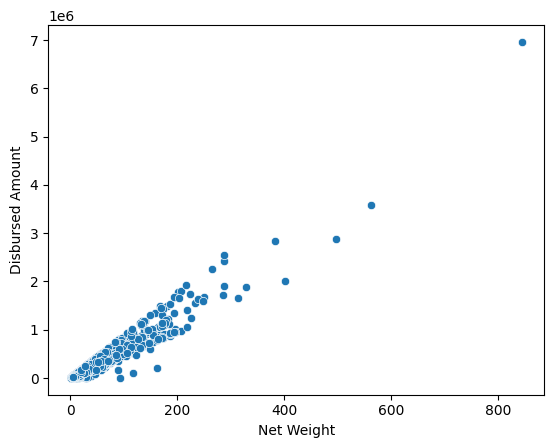

In [59]:
df_sample = df.sample(10000)

sns.scatterplot(x="Net Weight", y="Disbursed Amount", data=df_sample)

<Axes: xlabel='State'>

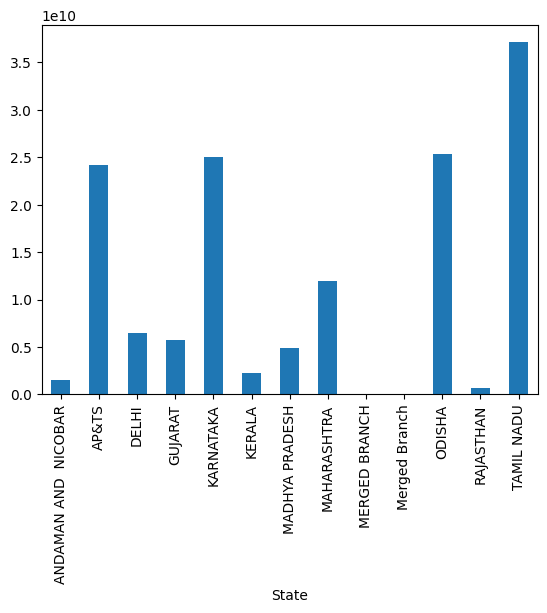

In [62]:
df_vis.groupby("State")["Disbursed Amount"].sum().plot(kind="bar")

<Axes: xlabel='Scheme'>

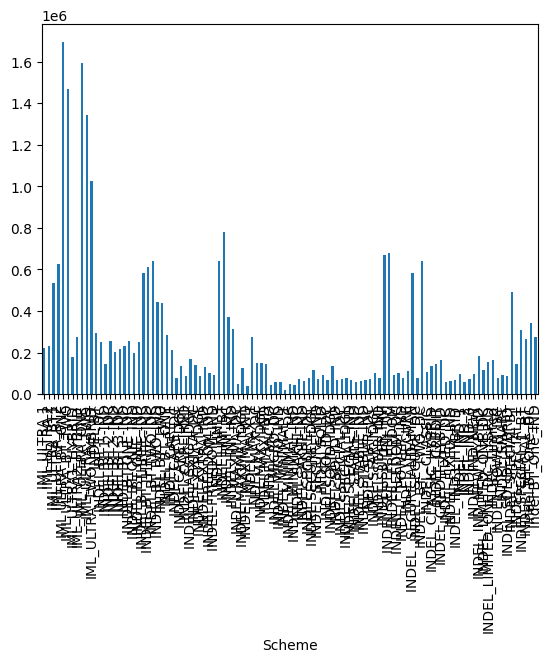

In [63]:
df_vis.groupby("Scheme")["Disbursed Amount"].mean().plot(kind="bar")

<Axes: xlabel='Month'>

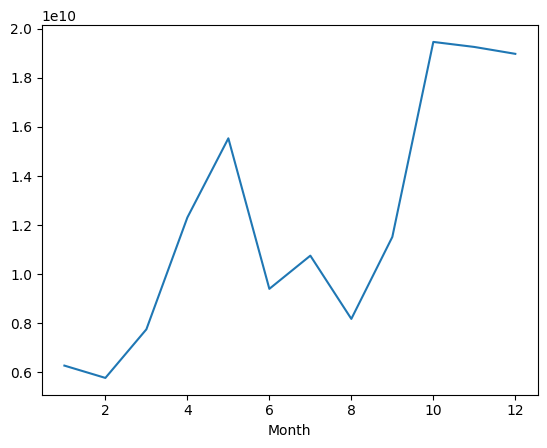

In [64]:
df_vis["Date of Loan"] = pd.to_datetime(df_vis["Date of Loan"])
df_vis["Month"] = df_vis["Date of Loan"].dt.month

df_vis.groupby("Month")["Disbursed Amount"].sum().plot(kind="line")

<Axes: xlabel='Net Weight', ylabel='Disbursed Amount'>

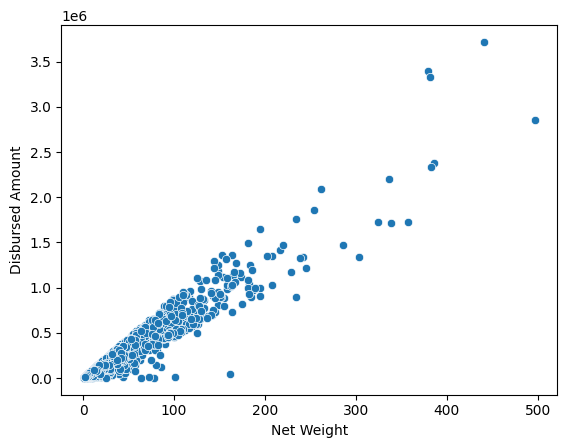

In [65]:
import seaborn as sns

sns.scatterplot(x="Net Weight", y="Disbursed Amount", data=df_vis.sample(10000))

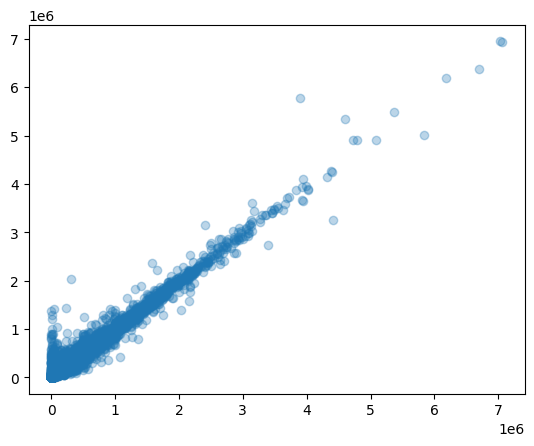

In [66]:
plt.scatter(y_test, y_pred, alpha=0.3)